# Project 4 - Error Mitigation

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import math
from IPython.display import display
import random
from scipy.optimize import curve_fit

from qiskit import QuantumCircuit, transpile
from qiskit_aer import QasmSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error, thermal_relaxation_error, ReadoutError, coherent_unitary_error

In [3]:
SHOTS = 2048

# Standard IBM set
BASIS_GATES = ['id', 'rz', 'sx', 'x', 'cx', 'sxdg']

## Noise Models

### Depolarizing Error

In [4]:
# Define probability of error
p1 = 0.01
p2 = 0.02

# Create depolarizing errors
error_1q = depolarizing_error(p1, 1)
error_2q = depolarizing_error(p2, 2)

# Create noise model
noise_model_1 = NoiseModel()
noise_model_1.add_all_qubit_quantum_error(error_1q, ['id', 'rz', 'sx', 'x'])
noise_model_1.add_all_qubit_quantum_error(error_2q, ['cx'])

# Create backend
backend_noise_1 = QasmSimulator(noise_model=noise_model_1, basis_gates=BASIS_GATES)

### Thermal Relaxation

In [5]:
T1 = 28e3   # ns (289 us)
T2 = 33e3   # ns (500 us)

t_1q = 50   # ns, 1q gate time
t_2q = 300  # ns, 2q gate time

error_1q = thermal_relaxation_error(T1, T2, t_1q)
error_2q = thermal_relaxation_error(T1, T2, t_2q).tensor(thermal_relaxation_error(T1, T2, t_2q))

# Create noise model
noise_model_2 = NoiseModel()
noise_model_2.add_all_qubit_quantum_error(error_1q, ['id', 'rz', 'sx', 'x'])
noise_model_2.add_all_qubit_quantum_error(error_2q, ['cx'])

# Create backend
backend_noise_2 = QasmSimulator(noise_model=noise_model_2, basis_gates=BASIS_GATES)


### Readout Error

In [6]:
# Confusion matrix: P(meas|true)
p01 = 0.05  # (5e-3)
p10 = 0.08
ro = ReadoutError([[1 - p01, p01],
                   [p10, 1 - p10]])

# Create noise model
noise_model_4 = NoiseModel()
noise_model_4.add_all_qubit_readout_error(ro)

# Create backend
backend_noise_4 = QasmSimulator(noise_model=noise_model_4, basis_gates=BASIS_GATES)

### Coherent Unitary Error

In [7]:
def rx_matrix(theta):
    c = np.cos(theta / 2.0)
    s = np.sin(theta / 2.0)
    return np.array([[c, -1j * s],
                     [-1j * s, c]], dtype=complex)

# coherent over-rotation angle (radians)
delta = 0.02

# Error after sx and after sxdg with opposite sign
error_sx   = coherent_unitary_error(rx_matrix(+delta))
error_sxdg = coherent_unitary_error(rx_matrix(-delta))

noise_model_5 = NoiseModel()
noise_model_5.add_all_qubit_quantum_error(error_sx,   ['sx'])
noise_model_5.add_all_qubit_quantum_error(error_sxdg, ['sxdg'])

# Create backend
backend_noise_5 = QasmSimulator(noise_model=noise_model_5, basis_gates=BASIS_GATES)

In [8]:
noise_model_6 = NoiseModel()
noise_model_6.add_all_qubit_quantum_error(error_1q, ['id', 'rz', 'sx', 'x'])
noise_model_6.add_all_qubit_quantum_error(error_2q, ['cx'])
noise_model_6.add_all_qubit_readout_error(ro)
noise_model_6.add_all_qubit_quantum_error(error_sx,   ['sx'])
noise_model_6.add_all_qubit_quantum_error(error_sxdg, ['sxdg'])

# Create backend
backend_noise_6 = QasmSimulator(noise_model=noise_model_6, basis_gates=BASIS_GATES)


## Backends

In [9]:
backend_noiseless = QasmSimulator(basis_gates=BASIS_GATES)

# Create backend list of dictionaries
backends = [
    {"name": "Depolarizing Error", "backend": backend_noise_1},
    {"name": "Thermal Relaxation", "backend": backend_noise_2},
    {"name": "Readout Error", "backend": backend_noise_4},
    {"name": "Coherent Unitary Error", "backend": backend_noise_5},
    {"name": "Realistic Error", "backend": backend_noise_6},
]


## Circuit Folding

In [10]:
def circuit_folding(circuit, scale_factor=1.0):
    """
    Applies global circuit folding to a quantum circuit to scale noise by a factor lambda.
    
    Procedure:
    1. Calculate d (depth).
    2. Calculate integer k from scale_factor (lambda).
    3. Determine n (full folds) and s (partial folds).
    4. Construct U -> U(U^dag U)^n (L_part^dag L_part).
    
    Args:
        circuit (QuantumCircuit): The input transpiled circuit (U).
        scale_factor (float): The target noise scale factor (lambda >= 1).
        
    Returns:
        QuantumCircuit: The folded circuit with scaled noise.
    """
    ## Checks
    if scale_factor < 1.0:
        raise ValueError("Scale factor lambda must be >= 1.")


    ## Compute number of full folds and partial folds
    # Determine d: The depth or number of unitary layers/gates
    qc = circuit.remove_final_measurements(inplace=False)
    ops = qc.data
    d = len(ops)
    
    # Determine k: The closest integer to d(lambda - 1)/2
    target_k = d * (scale_factor - 1) / 2
    k = int(np.round(target_k))
    
    # Determine n and s
    n = k // d
    s = k % d
    

    ## Create folded circuit
    # Start with original circuit
    folded_qc = qc.copy()
    folded_qc.barrier()
    
    # Create the full folding block: (U^dag U)
    u_dag = qc.inverse()
    full_fold_block = u_dag.compose(qc)
    
    # Apply n integer foldings (U^dag U)^n
    for _ in range(n):
        folded_qc.compose(full_fold_block, inplace=True)
        folded_qc.barrier()
        
    # Apply final partial folding if s > 0
    if s > 0:
        # Extract the last s layers
        last_s = ops[-s:]
        
        # Create a temporary circuit for these s instructions to easily invert them
        l_s_circuit = qc.copy_empty_like()
        for i in last_s:
            l_s_circuit.append(i.operation, i.qubits, i.clbits)
            
        # Create the partial fold block: L_s^dag L_s
        l_s_inverse = l_s_circuit.inverse()
        partial_fold_block = l_s_inverse.compose(l_s_circuit)
    
        folded_qc.compose(partial_fold_block, inplace=True)
        
        folded_qc.barrier()

    folded_qc.measure_all()
    
    return folded_qc


## Layer Folding

In [11]:
def layer_folding(circuit, scale_factor = 1.0, method = 'right'):
    """
    Applies ZNE Layer (Gate) Folding to a transpiled circuit.
    
    Logic:
    - Base folding factor 'n' is applied to ALL gates.
    - An extra folding factor is applied to a subset 'S' of 's' gates.
    - The subset 'S' is determined by the 'method'.
    
    Args:
        circuit (QuantumCircuit): The input transpiled unitary circuit.
        scale_factor (float): Target noise scale lambda >= 1.
        method (str): Strategy to select the subset S. 
                      Options: 'left', 'right', 'random'.
                      
    Returns:
        QuantumCircuit: The folded circuit.
    """

    ## Checks
    if scale_factor < 1.0:
        raise ValueError("Scale factor lambda must be >= 1.")
        
    valid_methods = ['left', 'right', 'random']
    if method not in valid_methods:
        raise ValueError(f"Method must be one of {valid_methods}")
    
    ## Compute number of full folds and partial folds
    # Determine d: The depth or number of unitary layers/gates
    qc = circuit.remove_final_measurements(inplace=False)
    
    ops = [inst for inst in qc.data if inst.operation.name != "barrier"]
    d = len(ops)
    
    # Determine k: The closest integer to d(lambda - 1)/2
    target_k = d * (scale_factor - 1) / 2
    k = int(np.round(target_k))
    
    # Determine n and s
    n = k // d
    s = k % d
        
    ## Determine the subset S of indices to receive extra folding
    indx_extra = set()
    
    if s > 0:
        if method == 'left':
            # First s indices: {0, 1, ..., s-1}
            indx_extra = set(range(s))
            
        elif method == 'right':
            # Last s indices: {d-s, d-s+1, ..., d-1}
            indx_extra = set(range(d - s, d))
            
        elif method == 'random':
            # Random sample of s distinct indices from {0, ..., d-1}
            indx_extra = set(random.sample(range(d), s))

    ## Construct the Folded Circuit
    folded_qc = qc.copy_empty_like()
    
    for i, instruction in enumerate(ops):
        # Determine number of folds for this specific gate
        num_folds = n + 1 if i in indx_extra else n
        
        # Original Gate L
        folded_qc.append(instruction.operation, instruction.qubits, instruction.clbits)
        
        # Apply Folding: (L^dag L)^num_folds
        if num_folds > 0:
            inv_op = instruction.operation.inverse()
            orig_op = instruction.operation
            
            for _ in range(num_folds):
                folded_qc.append(inv_op, instruction.qubits, instruction.clbits)
                folded_qc.append(orig_op, instruction.qubits, instruction.clbits)
    
    folded_qc.measure_all()

    return folded_qc

## Grover's Algorithm

### Create Circuit
In this notebook we are going to see a simple implementation of the Grover algorithm on a database of dimension $N=8$ possibile data, so using $n=3$ qubits.

Between all the possibile state $|xyz\rangle$ , let's consider $|110 \rangle$ and $|101 \rangle$ as the solutions of our problem.

In [13]:
def apply_oracle(qc):
    """
    Oracle marks states |110> and |101>.
    """
    qc.cz(2, 0)
    qc.cz(2, 1)


def apply_reflection(qc):
    """
    Reflects about the state |000>.
    """
    n = qc.num_qubits
    
    # 1. Flip |0> to |1> so we can use a multi-controlled Z
    qc.x(range(n))
    
    # 2. Multi-controlled Z (MCZ)
    # Implemented as H -> MCX -> H on the target qubit
    qc.h(n-1)
    qc.mcx(list(range(n-1)), n-1)
    qc.h(n-1)
    
    # 3. Flip back
    qc.x(range(n))


def apply_grover_block(qc):
    """
    Applies one full Grover iteration
    """
    # Oracle
    apply_oracle(qc)
    qc.barrier()
    
    # Hadamard
    qc.h(range(qc.num_qubits))
    qc.barrier()
    
    # Diffuser
    apply_reflection(qc)
    qc.barrier()
    
    # Hadamard
    qc.h(range(qc.num_qubits))
    qc.barrier()


def create_grover_circuit(iterations=1):
    """
    Creates the full Grover circuit with 'iterations' number of blocks.
    """
    n_qubits = 3
    qc = QuantumCircuit(n_qubits)
    
    # Initialization (Equal Superposition)
    qc.h(range(n_qubits))
    qc.barrier()
    
    # Apply Grover Block k times
    for _ in range(iterations):
        apply_grover_block(qc)
    
    qc.measure_all()
    return qc

Grover circuit BEFORE transpiling.


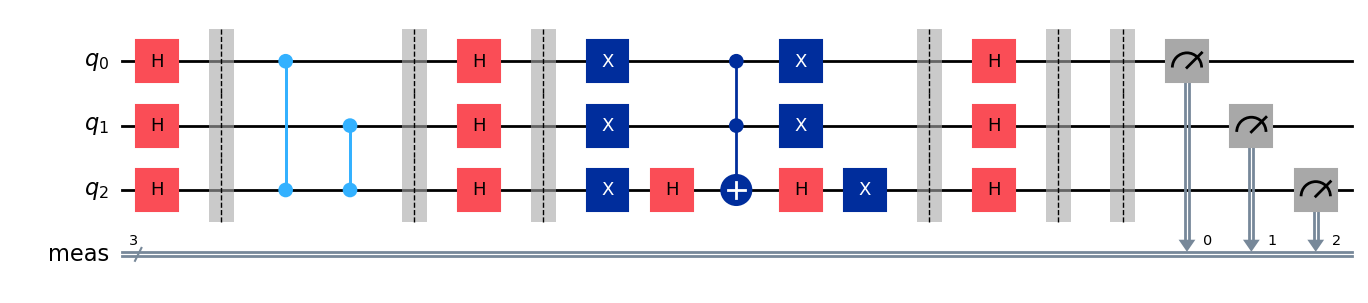

Grover circuit AFTER transpiling.


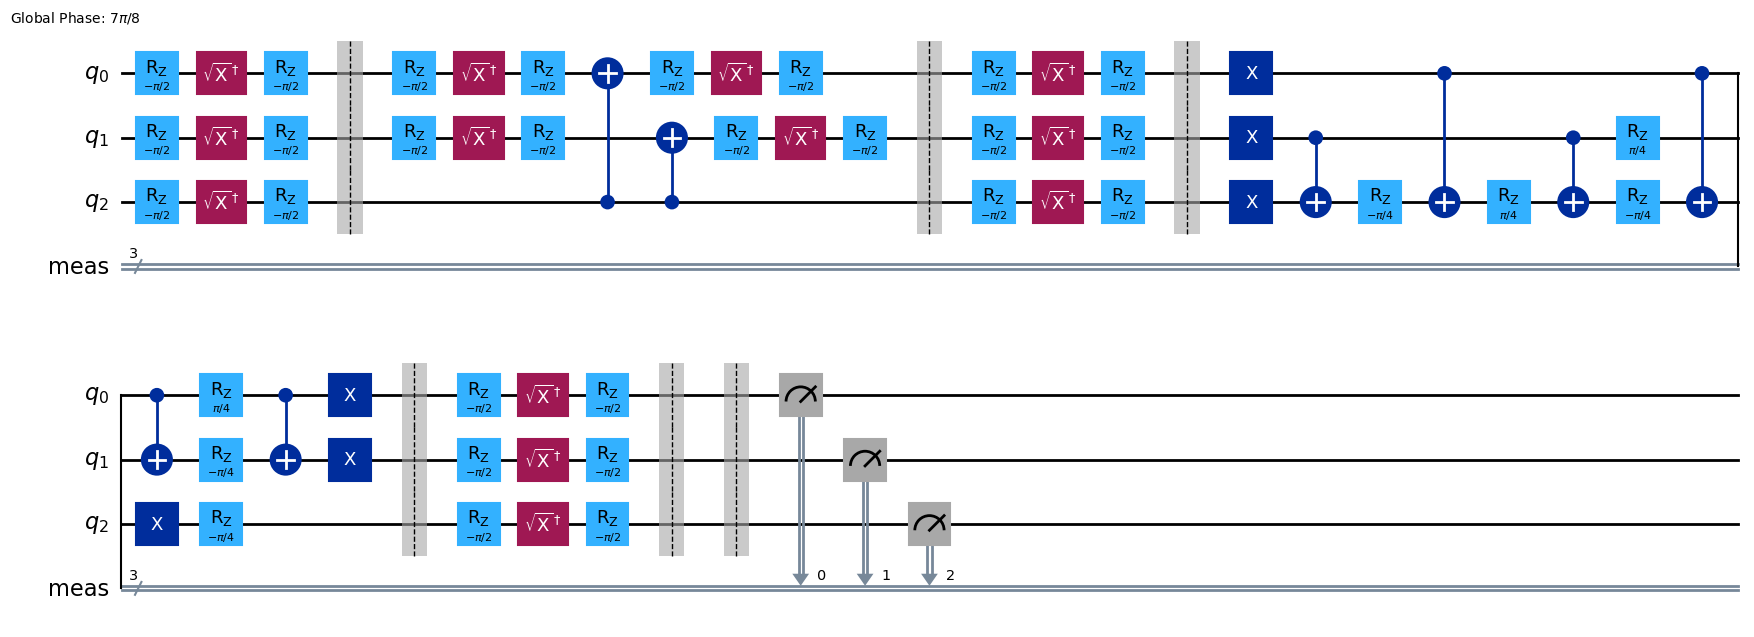

In [14]:
grover = create_grover_circuit(1)
grover.draw('mpl')

grover_trans = transpile(grover, basis_gates=BASIS_GATES)

print('Grover circuit BEFORE transpiling.')
display(grover.draw("mpl"))

print('Grover circuit AFTER transpiling.')
display(grover_trans.draw("mpl"))

### Circuit Folding

Original Depth (d): 30
Folded Depth: 88
Theoretical Scaling: 3
Actual Scaling: 2.933

Grover circuit BEFORE circuit folding.


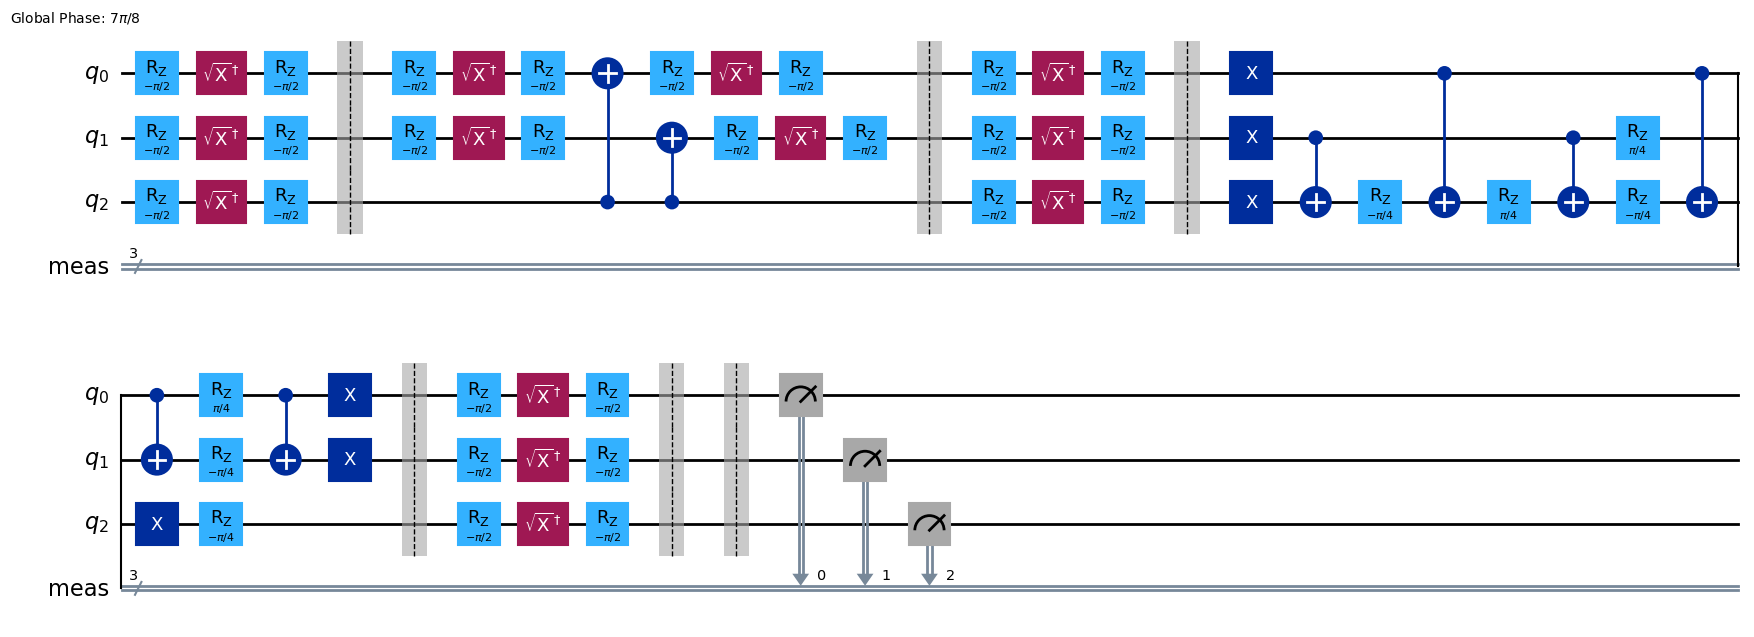

Grover circuit AFTER circuit folding.


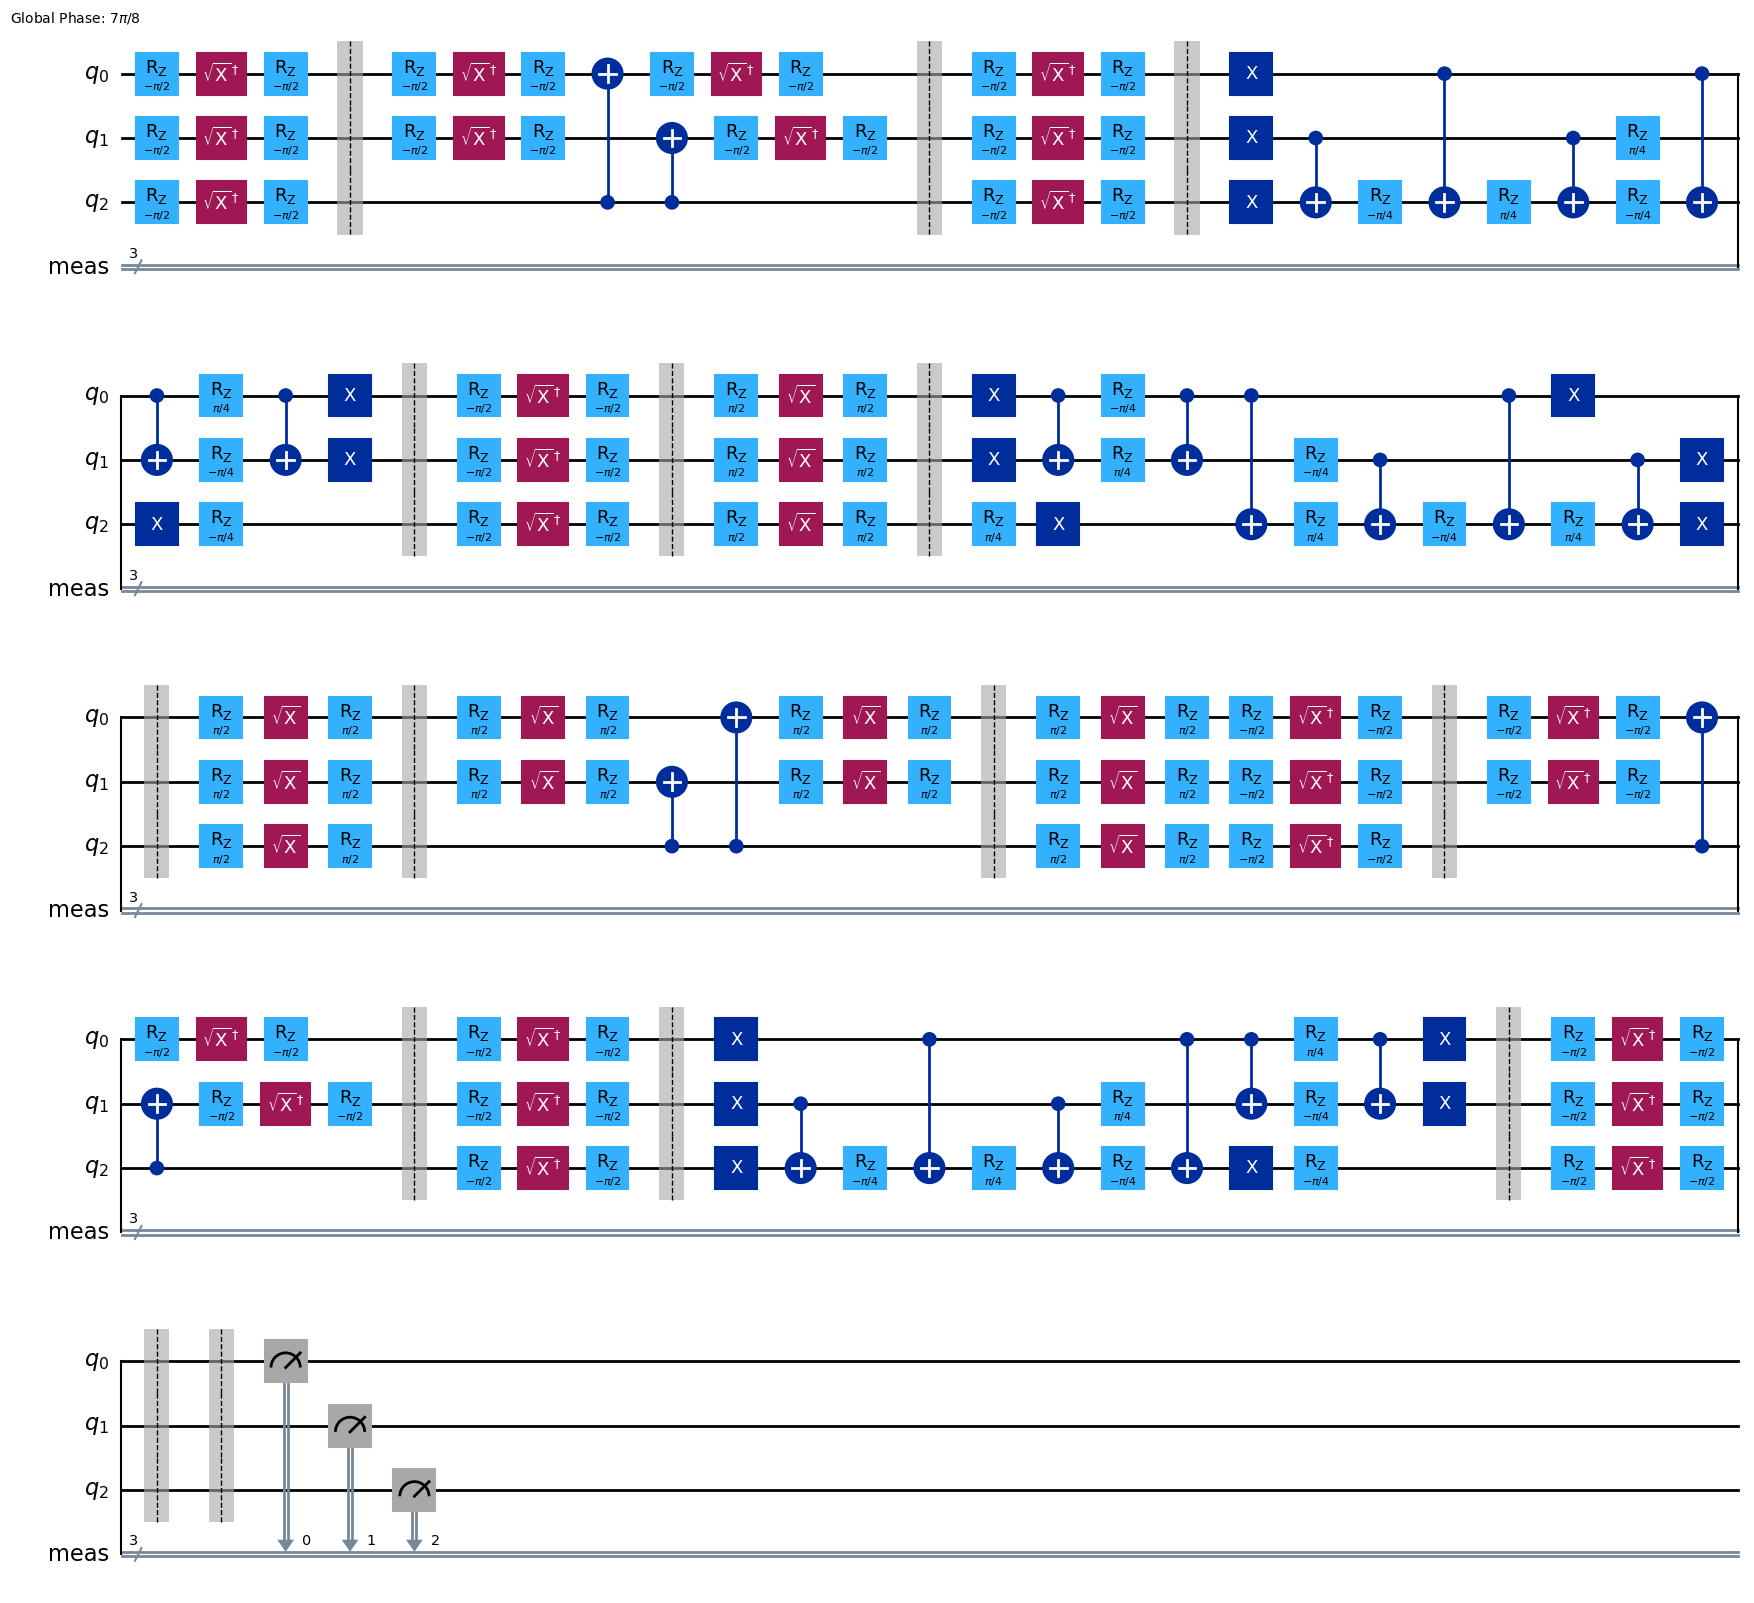

In [15]:
scale_factor = 3
grover_circuit_folded = circuit_folding(grover_trans, scale_factor=scale_factor)

print(f"Original Depth (d): {grover_trans.depth()}")
print(f"Folded Depth: {grover_circuit_folded.depth()}")
print(f"Theoretical Scaling: {scale_factor}")
print(f"Actual Scaling: {grover_circuit_folded.depth()/grover_trans.depth():.3f}")


print("\nGrover circuit BEFORE circuit folding.")
display(grover_trans.draw("mpl"))

print("Grover circuit AFTER circuit folding.")
display(grover_circuit_folded.draw("mpl"))

### Layer Folding

Original Depth (d): 30
Folded Depth: 88
Theoretical Scaling: 3
Actual Scaling: 2.933

Grover circuit BEFORE layer folding.


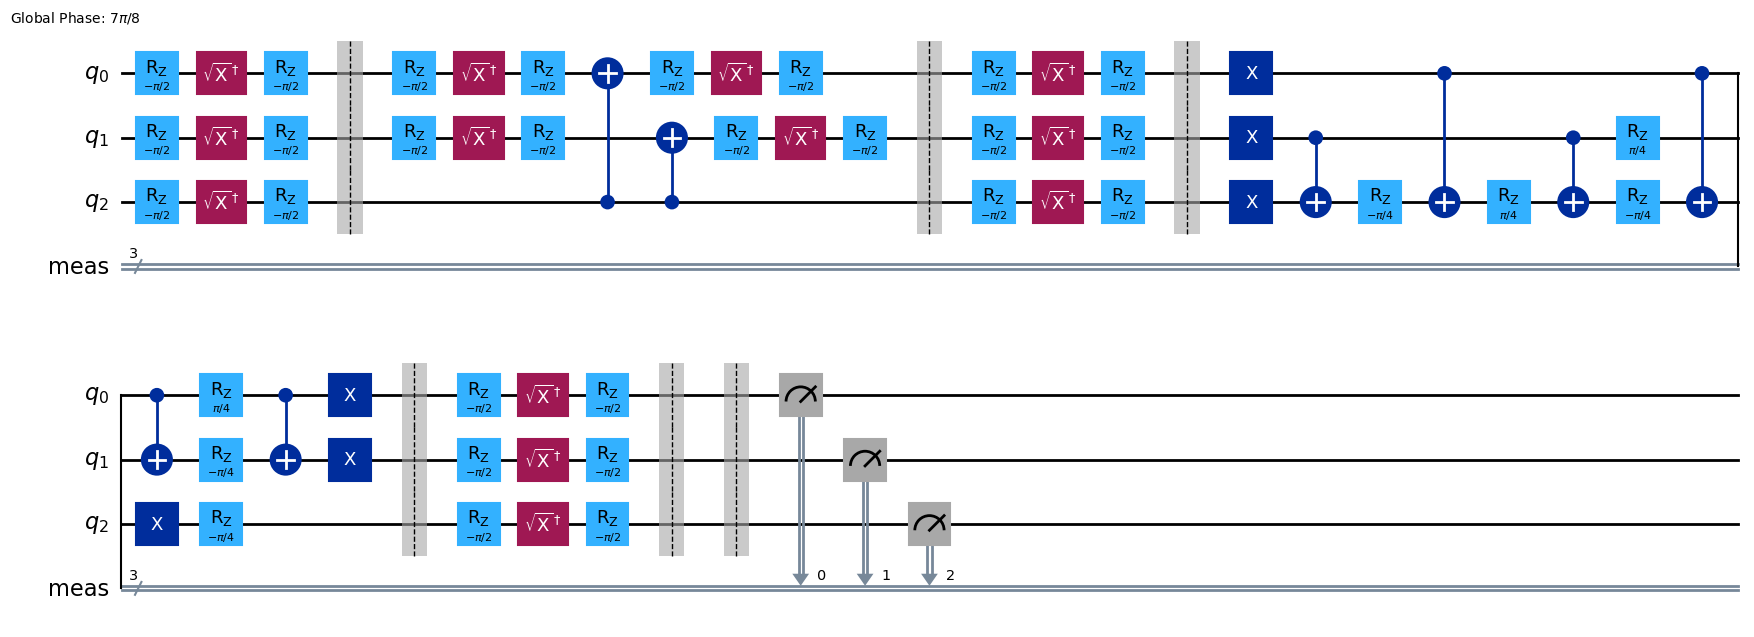

Grover circuit AFTER layer folding.


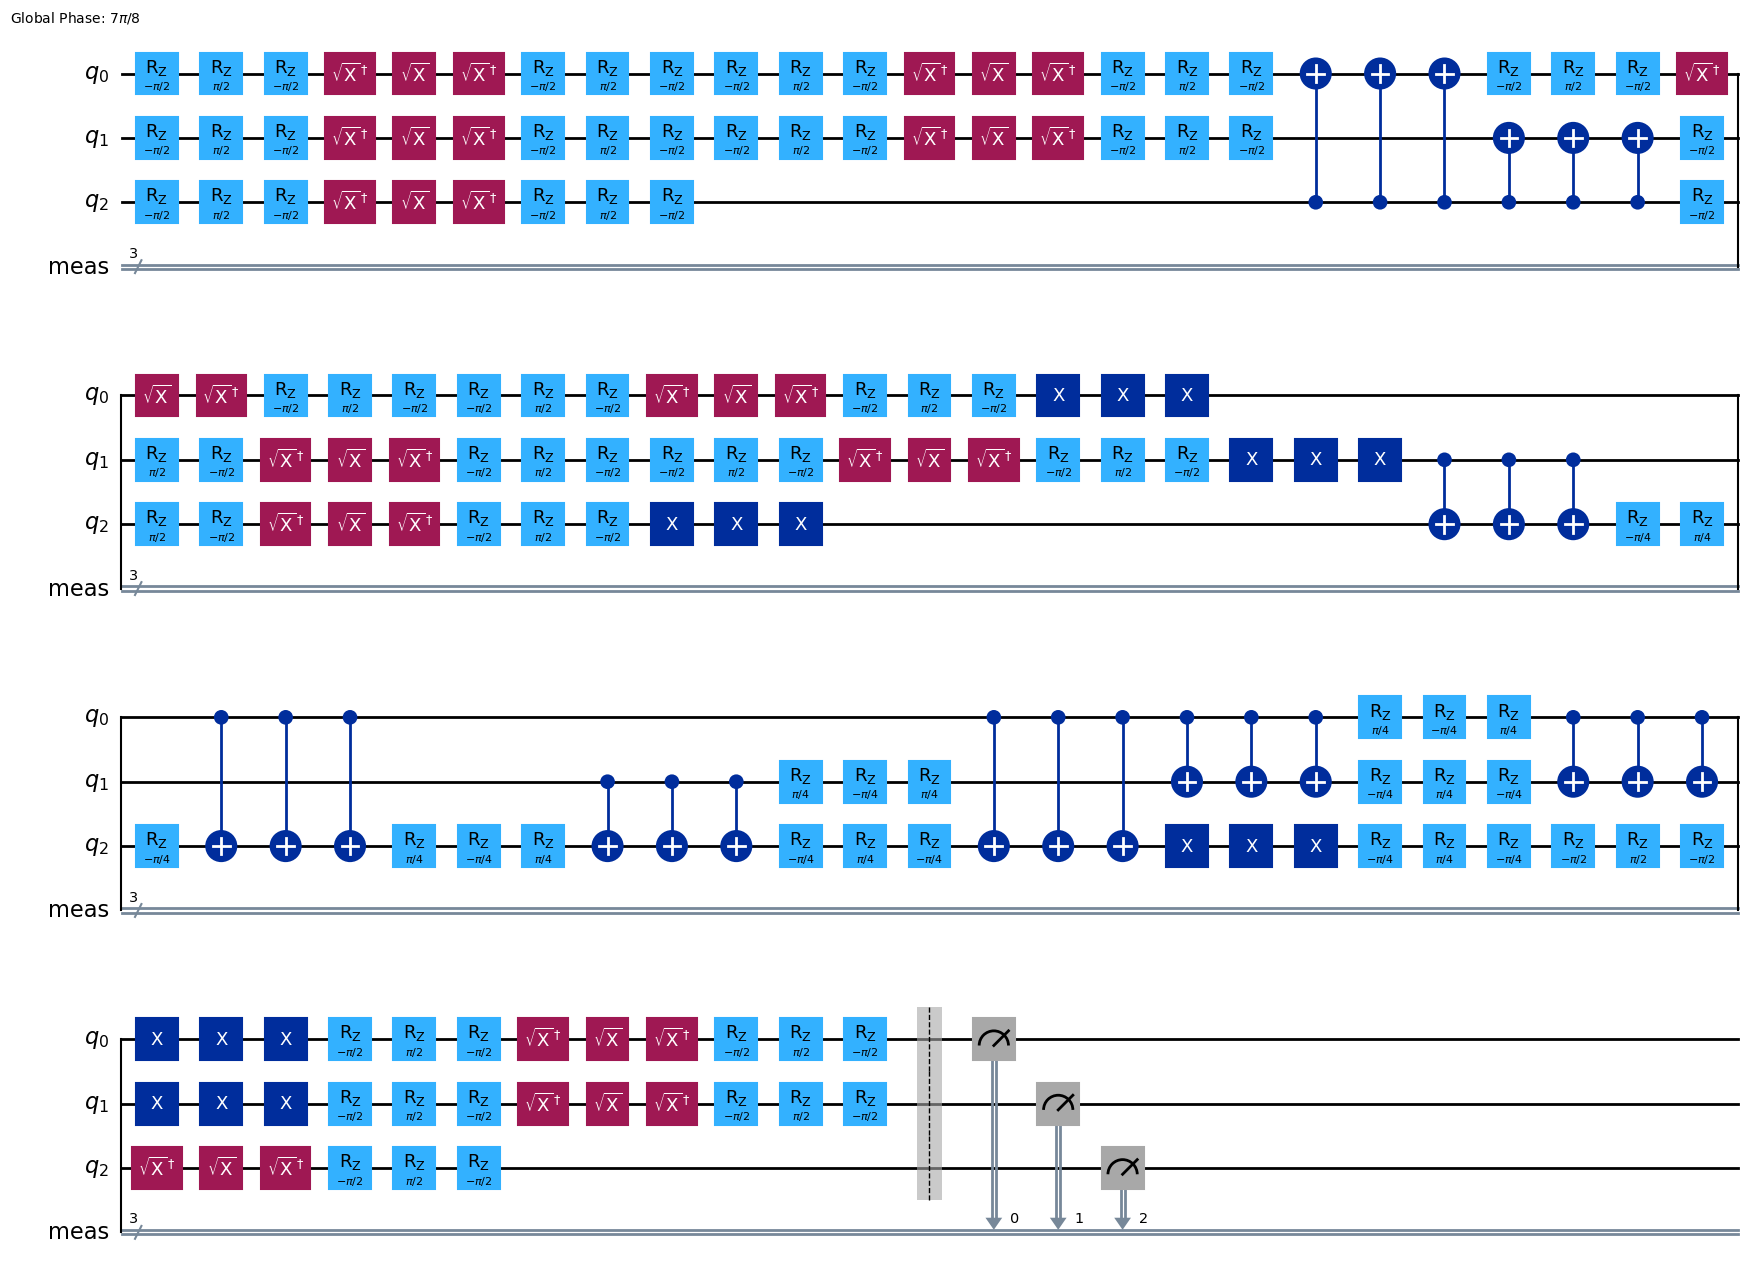

In [16]:
scale_factor = 3
grover_layer_folded = layer_folding(grover_trans, scale_factor=scale_factor)

print(f"Original Depth (d): {grover_trans.depth()}")
print(f"Folded Depth: {grover_layer_folded.depth()}")
print(f"Theoretical Scaling: {scale_factor}")
print(f"Actual Scaling: {grover_layer_folded.depth()/grover_trans.depth():.3f}")

print("\nGrover circuit BEFORE layer folding.")
display(grover_trans.draw("mpl"))

print("Grover circuit AFTER layer folding.")
display(grover_layer_folded.draw("mpl"))

## Extrapolation

### Linear Extrapolation

In [17]:
def linear_extrapolation(expectation_values, lambdas=(1, 3, 5), plot=False):
    """
    Performs Linear Zero-Noise Extrapolation (ZNE) by fitting:
        E(lambda) = m * lambda + c
    and returning the extrapolated value E(0) = c.
    """
    lambdas = np.asarray(lambdas, dtype=float).reshape(-1)
    expectation_values = np.asarray(expectation_values, dtype=float).reshape(-1)

    # Checks
    if lambdas.size != expectation_values.size:
        raise ValueError("lambdas and expectation_values must have the same length.")
    if lambdas.size < 2:
        raise ValueError("Need at least 2 (lambda, E) points for linear extrapolation.")

    order = np.argsort(lambdas)
    lambdas = lambdas[order]
    expectation_values = expectation_values[order]

    # Fit y = m*lambda + c
    m, c = np.polyfit(lambdas, expectation_values, deg=1)
    mitigated_value = float(c)  # E(0)

    x_fit = np.linspace(0.0, float(lambdas.max()) * 1.05, 200)
    y_fit = m * x_fit + c
    label = f"Linear fit"

    if plot:
        plt.figure(figsize=(10, 6))
        plt.plot(lambdas, expectation_values, "o", label="Measured")

        plt.plot(x_fit, y_fit, "-", color="darkorange", label=label)
        plt.plot(0.0, mitigated_value, "x", color="darkorange", label=f"Extrapolated E(0) = {mitigated_value:.3f}")
        
        plt.plot(0.0, 1.0, "*", color="green", markersize=10, label=f"Expected E(0) = 1.0")

        plt.axvline(1.0, color='royalblue', linestyle=':', alpha=0.5, zorder=2, label=r'$\lambda = 1$')
        plt.xlabel(r'Noise Scale Factor ($\lambda$)')
        plt.ylabel(r'Expectation Value $E(\lambda)$')
        plt.title("Linear Zero-Noise Extrapolation")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.show()

    return x_fit, y_fit, label, mitigated_value


### Richardson Extrapolation

In [18]:
def richardson_extrapolation(expectation_values, lambdas=(1,3,5), plot=False):
    """
    Performs Richardson Extrapolation.
    """
    m = len(lambdas)
    degree = m - 1
    
    # Fit a polynomial of degree m-1
    coeffs = np.polyfit(lambdas, expectation_values, degree)
    
    # Evaluate at lambda=0
    mitigated_value = coeffs[-1]
    x_fit = np.linspace(0, max(lambdas) + 0.5, 100)
    y_fit = np.polyval(coeffs, x_fit)
    label=f'Richardson fit (deg={degree})'
    
    if plot:
        plt.figure(figsize=(10, 6))
        
        # Plot data
        plt.plot(lambdas, expectation_values, 'o', label='Measured')
        
        # Plot the curve
        plt.plot(x_fit, y_fit, '-', label=label, color='purple')
        
        # Mark result
        plt.plot(0, mitigated_value, 'x', color='purple', label=f'Extrapolated E(0): {mitigated_value:.3f}')
        plt.plot(0.0, 1.0, "*", color="green", markersize=10, label=f"Expected E(0) = 1.0")

        plt.axvline(1.0, color='gray', linestyle=
                    ':', alpha=0.5, label=r'$\lambda$ = 1')
        plt.xlabel(r'Noise Scale Factor ($\lambda$)')
        plt.ylabel(r'Expectation Value $E(\lambda)$')
        plt.title(f'Richardson Extrapolation (Order {degree})')
        plt.legend()
        plt.grid(alpha=0.3)
        plt.show()
        
    return x_fit, y_fit, label, mitigated_value

### Exponential Extrapolation

In [19]:
def exponential_extrapolation(expectation_values, lambdas, asymptote=None, plot=False, use_log_fit_if_asymptote=True):
    """
    Exponential ZNE using the ansatz
        E(λ) = a + b * exp(-c λ)
    """
    eps = 1e-12
    lambdas = np.asarray(lambdas, dtype=float).reshape(-1)
    y = np.asarray(expectation_values, dtype=float).reshape(-1)

    if lambdas.size != y.size:
        raise ValueError("lambdas and expectation_values must have the same length.")
    if np.any(~np.isfinite(lambdas)) or np.any(~np.isfinite(y)):
        raise ValueError("Inputs must be finite (no NaN/inf).")

    # Sort by lambda
    order = np.argsort(lambdas)
    lambdas = lambdas[order]
    y = y[order]

    # Check minimum number of points
    if asymptote is None and lambdas.size < 3:
        raise ValueError("Need at least 3 points to fit (a,b,c) when asymptote is unknown.")
    if asymptote is not None and lambdas.size < 2:
        raise ValueError("Need at least 2 points to fit (b,c) when asymptote is fixed.")

    ## Case 1: asymptote known, optional log-linear fit
    if asymptote is not None and use_log_fit_if_asymptote:
        # Fit log(|y - a| + eps) = z0 + z1 * λ  with z1 ~ -c, z0 ~ logb
        y_shift = np.abs(y - asymptote) + eps
        z = np.log(y_shift)

        # linear regression z = z0 + z1*λ
        z1, z0 = np.polyfit(lambdas, z, 1)
        c_fit = -float(z1)

        b_mag = float(np.exp(z0))
        # determine sign from first residual direction
        sign = np.sign((y[0] - asymptote))
        b_fit = sign * b_mag

        # value in λ=0: y = a + b
        mitigated_value = float(asymptote + b_fit)

        def fit_func(x):
            return asymptote + b_fit * np.exp(-c_fit * x)

        fit_label = f"Exp fit (fixed a={asymptote}, log-fit)"

    else:
        ## Case 2: standard nonlinear least squares
        if asymptote is not None:
            def model(lam, b, c):
                return asymptote + b * np.exp(-c * lam)

            p0 = [y[0] - asymptote, 0.5]
            # enforce c >= 0
            bounds = ([-np.inf, 0.0], [np.inf, np.inf])

            try:
                popt, _ = curve_fit(model, lambdas, y, p0=p0, bounds=bounds, maxfev=20000)
            except RuntimeError:
                # fallback: linear
                return float(np.polyfit(lambdas, y, 1)[-1])

            b_fit, c_fit = map(float, popt)
            mitigated_value = float(asymptote + b_fit)

            def fit_func(x):
                return asymptote + b_fit * np.exp(-c_fit * x)

            fit_label = f"Exp fit (fixed a={asymptote})"

        else:
            def model(lam, a, b, c):
                return a + b * np.exp(-c * lam)

            # initial guesses: a ~ last point, b ~ (first-last), c ~ 0.5
            p0 = [float(y[-1]), float(y[0] - y[-1]), 0.5]
            bounds = ([-np.inf, -np.inf, 0.0], [np.inf, np.inf, np.inf])  # enforce c >= 0

            try:
                popt, _ = curve_fit(model, lambdas, y, p0=p0, bounds=bounds, maxfev=20000)
            except RuntimeError:
                return float(np.polyfit(lambdas, y, 1)[-1])

            a_fit, b_fit, c_fit = map(float, popt)
            mitigated_value = float(a_fit + b_fit)

            def fit_func(x):
                return a_fit + b_fit * np.exp(-c_fit * x)

            fit_label = f"Exp fit (a={a_fit:.3g})"


    x_fit = np.linspace(0.0, float(lambdas.max()) * 1.05, 200)
    y_fit = fit_func(x_fit)
    
    if plot:
        plt.figure(figsize=(10, 6))
        plt.plot(lambdas, y, "o", label="Measured data")

        plt.plot(x_fit, y_fit, "-", color='magenta', label=fit_label)

        plt.plot(0.0, mitigated_value, "x", color='magenta', label=f"Extracted E(0)={mitigated_value:.3f}")
        plt.plot(0.0, 1.0, "*", color="green", markersize=10, label=f"Expected E(0) = 1.0")

        plt.axvline(1.0, color='gray', linestyle=':', alpha=0.5, label=r'$\lambda$ = 1')
        plt.xlabel(r'Noise Scale Factor ($\lambda$)')
        plt.ylabel(r'Expectation Value $E(\lambda)$')
        plt.title("Exponential Zero-Noise Extrapolation")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.show()

    return x_fit, y_fit, fit_label, mitigated_value


## Run Non-Adaptive Extrapolation

In [28]:
def grover_expectation(counts, solutions=("101", "110")):
    """
    Compute Grover's "success probability" from measurement counts.
    """
    shots = sum(counts.values())
    return sum(counts.get(s, 0) for s in solutions) / shots

def compute_expectations(lambdas, folding_method, backend, iterations=1, max_shots=None, plot=False):
    qc = create_grover_circuit(iterations=iterations)
    qc_trans = transpile(qc, basis_gates=BASIS_GATES)
    
    valid_methods = ['circuit', 'layer']
    if folding_method not in valid_methods:
        raise ValueError(f"Method must be one of {valid_methods}")
    
    # Split max_shots across lambdas
    if max_shots is not None:
        shots = int(np.floor(max_shots/len(lambdas)))
        # print(f"Using {shots} shots.")
    else:
        shots = SHOTS

    expectations = []
    for l in lambdas:
        qc_folded = circuit_folding(circuit=qc_trans, scale_factor=l)
        results = backend.run(qc_folded, shots=shots).result()
        answer = results.get_counts()
        
        if plot:
            plt.suptitle(f"Results of Grover's algorithm ({folding_method} folding)")
            plt.bar(answer.keys(), answer.values(), color='royalblue')
            plt.show()

        exp = grover_expectation(answer)
        expectations.append(exp)

    return expectations


In [29]:
def run_unmitigated(max_shots=None, plot=False, backend=backend_noise_1, iterations=1):
    qc = create_grover_circuit(iterations=iterations)
    qc_trans = transpile(qc, basis_gates=BASIS_GATES)
    
    if max_shots is not None:
        shots = int(np.floor(max_shots))
    else:
        shots = SHOTS

    results = backend.run(qc_trans, shots=shots).result()
    answer = results.get_counts()
        
    if plot:
        plt.suptitle(f"Results of Grover's algorithm (unmitigated)")
        plt.bar(answer.keys(), answer.values(), color='royalblue')
        plt.show()

    exp = grover_expectation(answer)
    # print(f"Unmitigated: {exp:.3f}")

    return exp

In [30]:
def run_non_adaptive_extrapolation(lambdas=(1, 3, 5), folding_method='circuit', plot=False, plot_sum=True, max_shots=None, comparison=False, backend=backend_noise_1):
    """
    Run Grover's circuit at multiple noise scale factors (lambdas) using ZNE folding,
    compute the success probability E(lambda) = P(solution), and apply
    zero-noise extrapolation to estimate E(0).
    """
    if max_shots is not None:
        max_shots = int(np.floor(max_shots))
        expectations = compute_expectations(lambdas, folding_method, max_shots=max_shots, backend=backend)
        title = f"Non-Adaptive Zero-Noise Extrapolation (N_max = {max_shots})."
        title_plot = rf"Non-Adaptive Zero-Noise Extrapolation $(N_{{max}} = {max_shots})$"
    else:
        expectations = compute_expectations(lambdas, folding_method, backend=backend)
        title = "Non-Adaptive Zero-Noise Extrapolation."
        title_plot = "Non-Adaptive Zero-Noise Extrapolation"

    if comparison:
        _, _, _, exp_ext = exponential_extrapolation(expectations, lambdas, asymptote=0.25)
        return exp_ext

    ideal = run_unmitigated(backend=backend_noiseless)
    unmitigated = run_unmitigated(backend=backend)
    lin_x, lin_y, lin_label, lin_ext = linear_extrapolation(expectations, lambdas, plot=plot)
    rich_x, rich_y, rich_label, rich_ext = richardson_extrapolation(expectations, lambdas, plot=plot)
    exp_x, exp_y, exp_label, exp_ext = exponential_extrapolation(expectations, lambdas, asymptote=0.25, plot=plot)

    print(title)
    print("===============================================================")
    print(f"Ideal E(0): {ideal:.3f}")
    print(f"Unmitigated E(1): {unmitigated:.3f}")
    print(f"Estimated E(0) (Linear estrapolation): {lin_ext:.3f}")
    print(f"Estimated E(0) (Richardson estrapolation): {rich_ext:.3f}")
    print(f"Estimated E(0) (Exponential estrapolation with guess): {exp_ext:.3f}")

    ## Summary plot
    if plot_sum:
        xmax = max(lambdas) + 0.2
        xmin = -0.2

        plt.figure(figsize=(10, 6))
        plt.xlim(xmin, xmax)

        # Shade area physically accessible
        ax = plt.gca()
        ax.axvspan(1.0, ax.get_xlim()[1], alpha=0.2, color="royalblue", zorder=0, label=r"Noisy region ($\lambda > 1$)")

        plt.plot(lambdas, expectations, "o", color="chocolate", label="Measured", zorder=5)

        # Plot Linear
        plt.plot(lin_x, lin_y, "-", color='magenta', label=lin_label, linewidth=0.7, zorder=1)
        plt.plot(0.0, lin_ext, "X", color='magenta', label=f"Linear E(0)={lin_ext:.3f}")

        # Plot Richardson
        plt.plot(rich_x, rich_y, "-", color='darkorchid', label=rich_label, linewidth=0.7, zorder=2)
        plt.plot(0.0, rich_ext, "s", color='darkorchid', label=f"Richardson E(0)={rich_ext:.3f}")

        # Plot Exponential
        plt.plot(exp_x, exp_y, "-", color='royalblue', label=exp_label, linewidth=0.7, zorder=3)
        plt.plot(0.0, exp_ext, "p", color='royalblue', label=f"Exponential E(0)={exp_ext:.3f}")

        plt.plot(0.0, 1.0, "*", color="green", label="Expected E(0)=1.0", zorder=4, markersize=10)

        plt.xlabel(r'Noise Scale Factor ($\lambda$)')
        plt.ylabel(r'Expectation Value $E(\lambda)$')
        plt.title(title_plot)
        plt.legend()
        plt.grid(alpha=0.3)
        plt.show()


Non-Adaptive Zero-Noise Extrapolation.
Ideal E(0): 1.000
Unmitigated E(1): 0.748
Estimated E(0) (Linear estrapolation): 0.754
Estimated E(0) (Richardson estrapolation): 1.520
Estimated E(0) (Exponential estrapolation with guess): 1.027


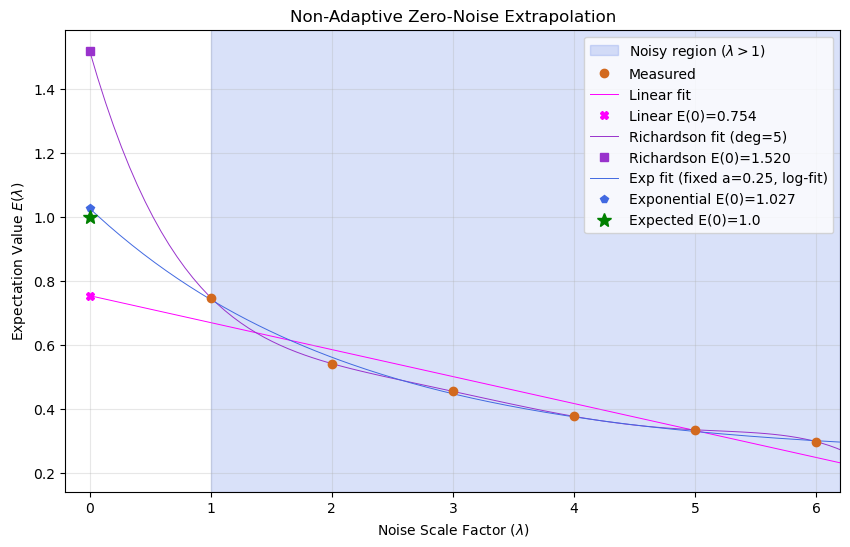

In [31]:
run_non_adaptive_extrapolation(backend=backend_noise_1, lambdas=np.arange(1,7))

## Run Adaptive Extrapolation

In [39]:
def fit_bc(lambdas, y, a=0.25, eps=1e-12):
    """
    BestFit for E(λ) = a + b exp(-c λ) with known a.
    """
    lambdas = np.asarray(lambdas, dtype=float).reshape(-1)
    y = np.asarray(y, dtype=float).reshape(-1)

    if lambdas.size < 2:
        raise ValueError("Need at least 2 points to fit (b,c) with fixed asymptote.")

    # Sort by lambda (helps stability/plotting)
    order = np.argsort(lambdas)
    lambdas = lambdas[order]
    y = y[order]

    # Linearize
    z = np.log(np.abs(y - a) + eps)

    # Fit z = z0 + z1*λ  =>  c = -z1, |b| = exp(z0)
    z1, z0 = np.polyfit(lambdas, z, 1)
    c_fit = max(0.0, -float(z1))

    b_mag = float(np.exp(z0))

    # Choose sign of b to match direction at smallest λ
    sign = np.sign(y[0] - a)
    if sign == 0:
        sign = 1.0
    b_fit = float(sign * b_mag)

    return b_fit, c_fit


def run_one_lambda_grover(qc_trans, lam, folding_method, backend, shots=SHOTS, show_hist=False):
    """
    Runs Grover circuit at a single noise scale factor lam
    """
    valid_methods = ['circuit', 'layer']
    if folding_method not in valid_methods:
        raise ValueError(f"Method must be one of {valid_methods}")
    
    if folding_method=='circuit':
        qc_folded = circuit_folding(circuit=qc_trans, scale_factor=lam)
    else:
        qc_folded = layer_folding(circuit=qc_trans, scale_factor=lam)
    results = backend.run(qc_folded, shots=shots).result()
    answer = results.get_counts()

    if show_hist:
        plt.figure(figsize=(8, 4))
        plt.title(f"Counts (λ={lam:.3g}, shots={shots}, {folding_method} folding)")
        plt.bar(answer.keys(), answer.values(), color='royalblue')
        plt.grid(alpha=0.2)
        plt.show()

    return grover_expectation(answer)


def run_adaptive_extrapolation(
    folding_method='circuit', a=0.25, lambda1=1.0, Nmax=10*SHOTS, Nbatch=2*SHOTS, c_init=1.0, 
    alpha=1.27846, shots_min=1, show_each_hist=False, plot=True, comparison=False, backend=backend_noise_1, 
    lambda_max=8, c_min=1e-4, iterations=1):
    """
    Run adaptive extrapolation.
    """
    # Checks
    if lambda1 < 1.0:
        raise ValueError("lambda1 should be >= 1.")
    if Nmax <= 0 or Nbatch <= 0:
        raise ValueError("Nmax and Nbatch must be positive.")
    if c_init <= 0:
        raise ValueError("c_init must be > 0.")
    if alpha <= 0:
        raise ValueError("alpha must be > 0.")

    # Prepare circuit
    qc = create_grover_circuit(iterations=iterations)
    qc_trans = transpile(qc, basis_gates=BASIS_GATES)

    # Algorithm 3 init: c <- 1, alpha fixed, data empty, Nused <- 0
    c = float(c_init)
    lambdas_meas = []
    y_meas = []
    c_estimates = []
    Nused = 0

    while Nused < Nmax:
        # λ2 <- λ1 + α/c
        lambda2 = float(lambda1 + alpha / c)
        lambda2 = min(lambda2, lambda_max) 

        # N1, N2
        denom = (c * lambda1 + alpha - 1.0)
        if denom <= 0:
            denom = 1e-12

        N1 = Nbatch * ((c * lambda1 / alpha) / denom)
        N2 = Nbatch * (((1.0 + c * lambda1 / alpha) * (alpha - 1.0)) / denom)

        # integer shots + minimum
        N1 = max(shots_min, int(round(N1)))
        N2 = max(shots_min, int(round(N2)))

        # Respect remaining budget
        remaining = Nmax - Nused
        total = N1 + N2
        if total > remaining:
            N1 = max(shots_min, int(math.floor(remaining * (N1 / total))))
            N2 = max(shots_min, remaining - N1)
            if N1 + N2 > remaining:
                N2 = max(shots_min, remaining - N1)

        if N1 + N2 <= 0:
            print("Not enough shots to continue.")
            break

        # Measure y1, y2
        y1 = run_one_lambda_grover(qc_trans, lambda1, folding_method, backend, shots=N1, show_hist=show_each_hist)
        y2 = run_one_lambda_grover(qc_trans, lambda2, folding_method, backend, shots=N2, show_hist=show_each_hist)

        lambdas_meas.extend([lambda1, lambda2])
        y_meas.extend([y1, y2])

        Nused += (N1 + N2)

        # Update c <- BestFit(...)
        b_fit, c_fit = fit_bc(lambdas_meas, y_meas, a=a)

        # Early stop
        if c_fit < c_min:
            # print(f"c_fit ~ {c_fit:.2e}. Stopping adaptation.")
            break

        c = max(1e-9, float(c_fit))
        c_estimates.append(c)

    # Final fit and output E(0) = a + b
    b_fit, c_fit = fit_bc(lambdas_meas, y_meas, a=a)
    mitigated_value = float(a + b_fit)

    # Build fitted curve for plotting
    x_fit = np.linspace(0.0, 11, 2000)
    y_fit = a + b_fit * np.exp(-c_fit * x_fit)
    label = f"Adaptive Exp (a={a}, final c={c_fit:.3g})"

    history = {
        "lambdas": lambdas_meas,
        "y": y_meas,
        "c_estimates": c_estimates,
        "N_used": Nused,
        "b_final": b_fit,
        "c_final": c_fit,
        "lambda1": lambda1,
        "alpha": alpha
    }

    if plot:
        plt.figure(figsize=(10, 6))
        xmax = max(lambdas_meas) + 0.2
        xmin = -0.2
        plt.xlim(xmin, xmax)

        ax = plt.gca()
        ax.axvspan(1.0, ax.get_xlim()[1], alpha=0.2, color="royalblue",
                   zorder=0, label=r"Noisy region ($\lambda > 1$)")

        plt.plot(lambdas_meas, y_meas, "o", color="chocolate", label="Measured (adaptive)", zorder=5)
        plt.plot(x_fit, y_fit, "-", color="magenta", label=label, linewidth=0.9, zorder=2)

        plt.plot(0.0, mitigated_value, "X", color="magenta", label=f"Adaptive E(0)={mitigated_value:.3f}", zorder=6)
        plt.plot(0.0, 1.0, "*", color="green", markersize=10, label="Expected E(0)=1.0", zorder=6)

        plt.axvline(1.0, color='gray', linestyle=':', alpha=0.5, label=r'$\lambda=1$')
        plt.xlabel(r'Noise Scale Factor ($\lambda$)')
        plt.ylabel(r'Expectation Value $E(\lambda)$')
        plt.title("Adaptive Exponential ZNE")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.show()
    
    if comparison:
        return mitigated_value
    else:
        return x_fit, y_fit, label, mitigated_value, history


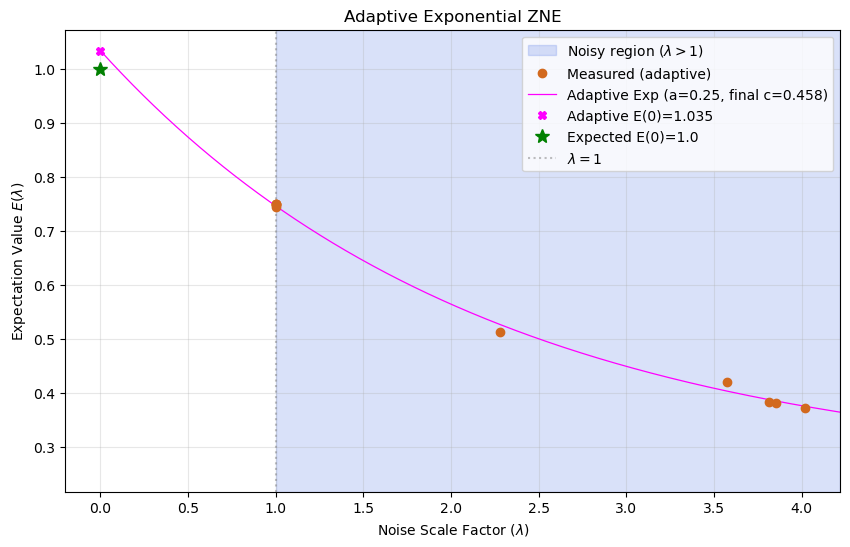

In [33]:
_,_,_,_,_ = run_adaptive_extrapolation(backend=backend_noise_1)

## Compare Adaptive and Non-Adaptive (N_shots)

In [34]:
def set_seed_backend(backend, seed):
    try:
        backend.set_options(seed_simulator=int(seed))
    except Exception:
        pass

def comparison_budget(
    backend_dict, 
    max_shots=np.arange(1000, 10000, 500), 
    n_reps=40,
    seed0=1234,
    ideal_shots=20000,
    iterations=1,
    folding_method="circuit",
    lambdas=(1, 3, 5),
):
    sel_backend = backend_dict["backend"]
    noise = backend_dict["name"]

    # Ideal reference
    set_seed_backend(backend_noiseless, seed0 + 99999)
    ideal_value = run_unmitigated(max_shots=ideal_shots, backend=backend_noiseless, iterations=iterations)
    ideal_value = float(ideal_value)
    print(f"Ideal reference (noiseless): {ideal_value:.6f}")

    # Store raw absolute errors: shape (len(max_shots), n_reps)
    err_uniform = np.zeros((len(max_shots), n_reps), dtype=float)
    err_adapt = np.zeros((len(max_shots), n_reps), dtype=float)
    err_unmit = np.zeros((len(max_shots), n_reps), dtype=float)

    for i_m, m in enumerate(max_shots):
        m = int(m)
        print(f"\nBudget m = {m} shots")
        for r in range(n_reps):
            seed = seed0 + 10000*m + r
            set_seed_backend(sel_backend, seed)
            uniform_est = run_non_adaptive_extrapolation(max_shots=m, comparison=True, plot_sum=False, backend=sel_backend, folding_method=folding_method, lambdas=lambdas)
            adaptive_est = run_adaptive_extrapolation(Nmax=m, comparison=True, plot=False, backend=sel_backend, folding_method=folding_method)
            unmitigated = run_unmitigated(max_shots=m, backend=sel_backend)

            # Absolute errors to the ideal
            err_uniform[i_m, r] = abs(float(uniform_est) - ideal_value)
            err_adapt[i_m, r] = abs(float(adaptive_est) - ideal_value)
            err_unmit[i_m, r] = abs(float(unmitigated) - ideal_value)

        # Print summary at this budget
        print(f"Uniform exp |err|: {err_uniform[i_m].mean():.4f} ± {err_uniform[i_m].std(ddof=1):.4f}")
        print(f"Adaptive exp |err|: {err_adapt[i_m].mean():.4f} ± {err_adapt[i_m].std(ddof=1):.4f}")
        print(f"Unmitigated |err|: {err_unmit[i_m].mean():.4f} ± {err_unmit[i_m].std(ddof=1):.4f}")

    # Mean ± std across repetitions
    mean_u, std_u = err_uniform.mean(axis=1), err_uniform.std(axis=1, ddof=1)
    mean_a, std_a = err_adapt.mean(axis=1), err_adapt.std(axis=1, ddof=1)
    mean_n, std_n = err_unmit.mean(axis=1), err_unmit.std(axis=1, ddof=1)

    # Plot with error bars
    plt.figure(figsize=(12, 6))
    plt.errorbar(max_shots, mean_n, yerr=std_n*0.5, fmt="o-", color="royalblue", label="Unmitigated", capsize=3, zorder=1) 
    plt.errorbar(max_shots, mean_u, yerr=std_u*0.5, fmt="p-", color="magenta", label="Mitigated: uniform exponential", capsize=3, zorder=2)
    plt.errorbar(max_shots, mean_a, yerr=std_a*0.5, fmt="X-", color="green", label="Mitigated: adaptive exponential", capsize=3, zorder=3)

    plt.xlabel(r"$N_{shots}$")
    plt.ylabel(r"$|E_{model}(0) - E_{ideal}(0)|$")
    plt.title(fr"Fixed-$N_{{shots}}$ Comparison ({noise})")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    return {
        "max_shots": np.asarray(max_shots, dtype=int),
        "ideal": ideal_value,
        "err_raw": {
            "uniform_exp": err_uniform,
            "adaptive_exp": err_adapt,
            "unmitigated": err_unmit,
        },
        "err_mean": {
            "uniform_exp": mean_u,
            "adaptive_exp": mean_a,
            "unmitigated": mean_n,
        },
        "err_std": {
            "uniform_exp": std_u,
            "adaptive_exp": std_a,
            "unmitigated": std_n,
        }
    }

Ideal reference (noiseless): 1.000000

Budget m = 1000 shots
Uniform exp |err|: 0.0552 ± 0.0449
Adaptive exp |err|: 0.0619 ± 0.0388
Unmitigated |err|: 0.2545 ± 0.0119

Budget m = 1500 shots
Uniform exp |err|: 0.0585 ± 0.0500
Adaptive exp |err|: 0.0731 ± 0.0422
Unmitigated |err|: 0.2527 ± 0.0107

Budget m = 2000 shots
Uniform exp |err|: 0.0428 ± 0.0439
Adaptive exp |err|: 0.0635 ± 0.0373
Unmitigated |err|: 0.2548 ± 0.0082

Budget m = 2500 shots
Uniform exp |err|: 0.0285 ± 0.0228
Adaptive exp |err|: 0.0657 ± 0.0281
Unmitigated |err|: 0.2584 ± 0.0086

Budget m = 3000 shots
Uniform exp |err|: 0.0313 ± 0.0265
Adaptive exp |err|: 0.0614 ± 0.0360
Unmitigated |err|: 0.2560 ± 0.0070

Budget m = 3500 shots
Uniform exp |err|: 0.0296 ± 0.0315
Adaptive exp |err|: 0.0698 ± 0.0355
Unmitigated |err|: 0.2537 ± 0.0063

Budget m = 4000 shots
Uniform exp |err|: 0.0285 ± 0.0201
Adaptive exp |err|: 0.0596 ± 0.0278
Unmitigated |err|: 0.2565 ± 0.0070

Budget m = 4500 shots
Uniform exp |err|: 0.0204 ± 0.0136
A

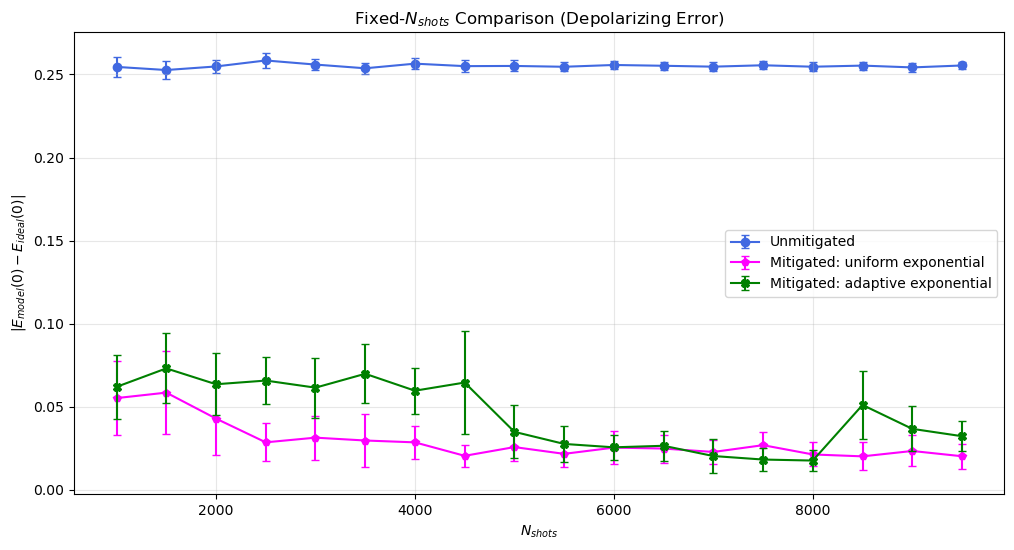

In [35]:
_ = comparison_budget(backends[0])

## Compare Noise Models

In [36]:
def run_extrapolation(backends, lambdas=(1, 3, 5), folding_method='circuit', plot=False, plot_sum=True):
    for backend_dict in backends:
        noise = backend_dict["name"]
        backend = backend_dict["backend"]
        # Non-adaptive
        expectations = compute_expectations(lambdas, folding_method, backend=backend)
        lin_x, lin_y, lin_label, lin_ext = linear_extrapolation(expectations, lambdas, plot=plot)
        rich_x, rich_y, rich_label, rich_ext = richardson_extrapolation(expectations, lambdas, plot=plot)
        exp_x, exp_y, exp_label, exp_ext = exponential_extrapolation(expectations, lambdas, asymptote=0.25, plot=plot)

        # Adaptive
        ad_x, ad_y, ad_label, ad_ext, history = run_adaptive_extrapolation(plot=plot, folding_method=folding_method, backend=backend)

        print(f"ZNE Estrapolation ({noise})")
        print("===============================================================")
        print(f"Estimated E(0) (Linear Estrapolation): {lin_ext:.3f}")
        print(f"Estimated E(0) (Richardson Estrapolation): {rich_ext:.3f}")
        print(f"Estimated E(0) (Uniform Exponential Estrapolation): {exp_ext:.3f}")
        print(f"Estimated E(0) (Adaptive Exponential Estrapolation): {ad_ext:.3f}")

        ## Summary plot
        if plot_sum:
            xmax = max(lambdas) + 0.2
            xmin = -0.2

            plt.figure(figsize=(10, 6))
            plt.xlim(xmin, xmax)

            # Shade area physically accessible
            ax = plt.gca()
            ax.axvspan(1.0, ax.get_xlim()[1], alpha=0.2, color="royalblue", zorder=0, label=r"Noisy region ($\lambda > 1$)")

            plt.plot(lambdas, expectations, "o", color="chocolate", label="Measured (non-adaptive)", zorder=5)
            plt.plot(history["lambdas"], history["y"], "o", color="orange", label="Measured (adaptive)", zorder=5)

            # Plot Linear
            plt.plot(lin_x, lin_y, "-", color='magenta', label=lin_label, linewidth=0.7, zorder=1)
            plt.plot(0.0, lin_ext, "X", color='magenta', label=f"Linear E(0)={lin_ext:.3f}")

            # # Plot Richardson
            plt.plot(rich_x, rich_y, "-", color='darkorchid', label=rich_label, linewidth=0.7, zorder=2)
            plt.plot(0.0, rich_ext, "s", color='darkorchid', label=f"Richardson E(0)={rich_ext:.3f}")

            # Plot Exponential
            plt.plot(exp_x, exp_y, "-", color='royalblue', label=exp_label, linewidth=0.7, zorder=3)
            plt.plot(0.0, exp_ext, "p", color='royalblue', label=f"Un. exponential E(0)={exp_ext:.3f}")

            # Plot Adaptive Exponential
            plt.plot(ad_x, ad_y, "-", color='green', label=ad_label, linewidth=0.7, zorder=4)
            plt.plot(0.0, ad_ext, "p", color='green', label=f"Ad. exponential E(0)={ad_ext:.3f}")

            plt.plot(0.0, 1.0, "*", color="lightgreen", label="Expected E(0)=1.0", zorder=4, markersize=10)

            plt.xlabel(r'Noise Scale Factor ($\lambda$)')
            plt.ylabel(r'Expectation Value $E(\lambda)$')
            plt.title(f"ZNE Estrapolation ({noise})")
            plt.legend()
            plt.grid(alpha=0.3)
            plt.show()

ZNE Estrapolation (Depolarizing Error)
Estimated E(0) (Linear Estrapolation): 0.661
Estimated E(0) (Richardson Estrapolation): 3.181
Estimated E(0) (Uniform Exponential Estrapolation): 1.060
Estimated E(0) (Adaptive Exponential Estrapolation): 1.035


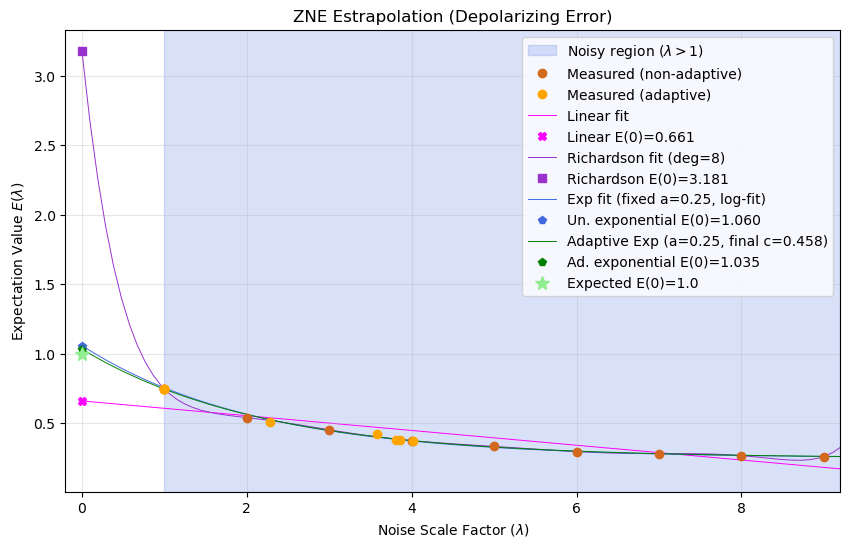

ZNE Estrapolation (Thermal Relaxation)
Estimated E(0) (Linear Estrapolation): 0.883
Estimated E(0) (Richardson Estrapolation): 9.021
Estimated E(0) (Uniform Exponential Estrapolation): 0.966
Estimated E(0) (Adaptive Exponential Estrapolation): 0.989


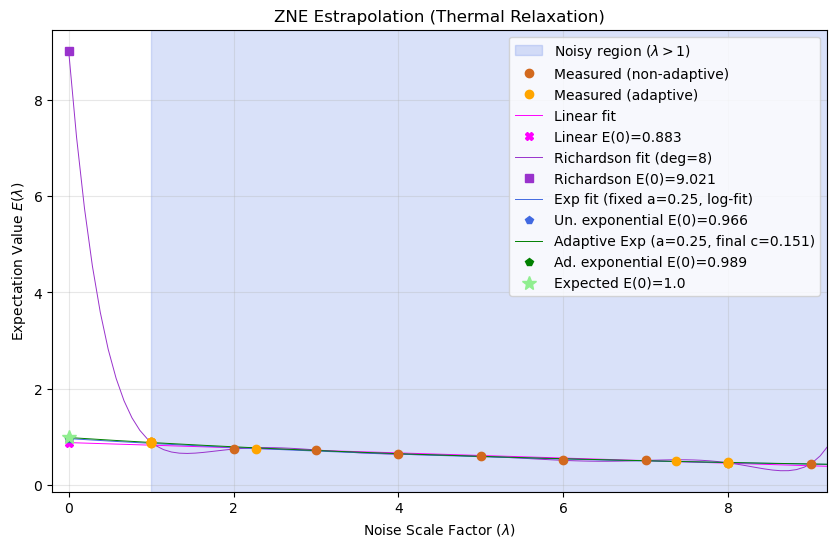

ZNE Estrapolation (Readout Error)
Estimated E(0) (Linear Estrapolation): 0.801
Estimated E(0) (Richardson Estrapolation): 0.372
Estimated E(0) (Uniform Exponential Estrapolation): 0.801
Estimated E(0) (Adaptive Exponential Estrapolation): 0.844


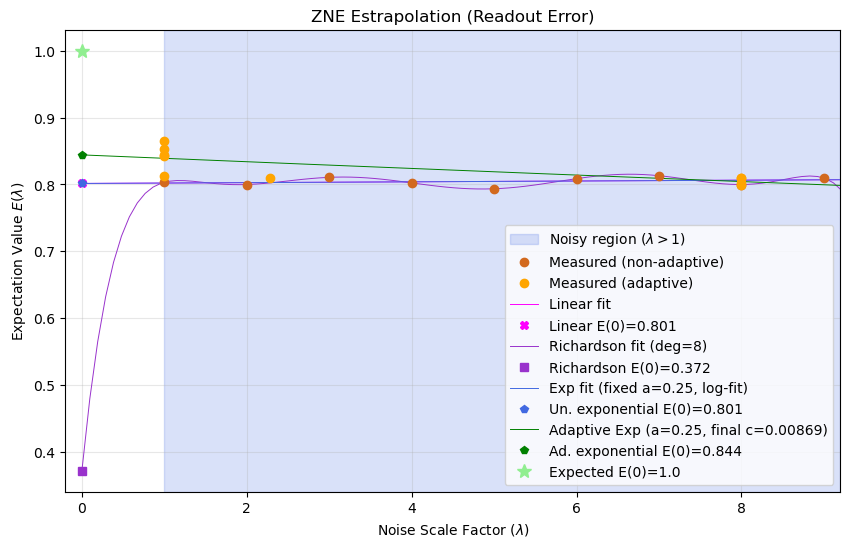

c_fit ~ 0.00e+00. Stopping adaptation.
ZNE Estrapolation (Coherent Unitary Error)
Estimated E(0) (Linear Estrapolation): 0.999
Estimated E(0) (Richardson Estrapolation): 0.969
Estimated E(0) (Uniform Exponential Estrapolation): 0.999
Estimated E(0) (Adaptive Exponential Estrapolation): 0.997


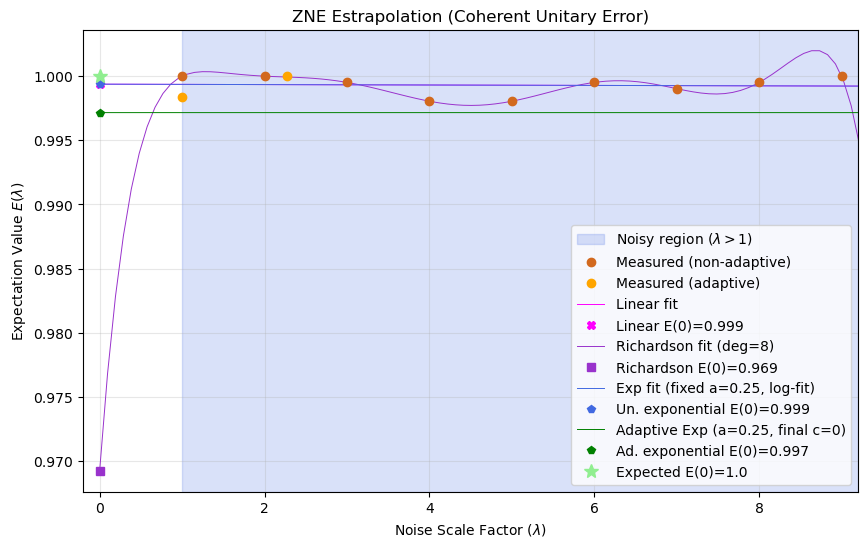

ZNE Estrapolation (Realistic Error)
Estimated E(0) (Linear Estrapolation): 0.724
Estimated E(0) (Richardson Estrapolation): 7.644
Estimated E(0) (Uniform Exponential Estrapolation): 0.792
Estimated E(0) (Adaptive Exponential Estrapolation): 0.808


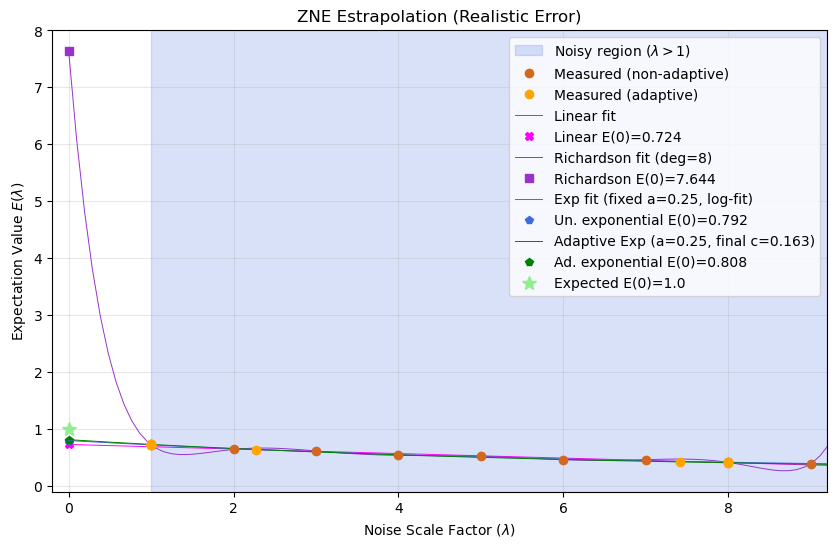

In [37]:
run_extrapolation(backends, lambdas=np.arange(1,10), folding_method='circuit')

## Compare Methods (Grover's iterations) 

In [38]:
def set_seed_backend(backend, seed):
    try:
        backend.set_options(seed_simulator=int(seed))
    except Exception:
        pass


def comparison_iterations(backend_dict, lambdas=(1, 3, 5), folding_method='circuit', plot=False, n_reps=10, seed0=1234, ideal_shots=20000,):
    noise = backend_dict["name"]
    backend = backend_dict["backend"]
    iterations = np.arange(1, 20)

    print(f"ZNE Extrapolation ({noise})")
    print("===============================================================")

    # Store raw errors (shape: [len(iterations), n_reps])
    err_un   = np.zeros((len(iterations), n_reps), dtype=float)
    err_lin  = np.zeros((len(iterations), n_reps), dtype=float)
    err_rich = np.zeros((len(iterations), n_reps), dtype=float)
    err_exp  = np.zeros((len(iterations), n_reps), dtype=float)
    err_ad   = np.zeros((len(iterations), n_reps), dtype=float)

    ideal_vals = np.zeros(len(iterations), dtype=float)

    for idx, k in enumerate(iterations):
        k = int(k)
        print(f"\nRunning k = {k}")

        # Ideal baseline (compute ONCE per k with many shots)
        set_seed_backend(backend_noiseless, seed0 + 100000 + k)
        ideal_value = run_unmitigated(backend=backend_noiseless, iterations=k, max_shots=ideal_shots)
        ideal_vals[idx] = float(ideal_value)

        # Repetitions on noisy backend
        for r in range(n_reps):
            seed = seed0 + 1000 * k + r
            set_seed_backend(backend, seed)

            # Unmitigated
            un_value = run_unmitigated(backend=backend, iterations=k)

            # Non-adaptive ZNE (uniform lambdas)
            expectations = compute_expectations(lambdas, folding_method, backend=backend, iterations=k)

            _, _, _, lin_ext  = linear_extrapolation(expectations, lambdas, plot=plot)
            _, _, _, rich_ext = richardson_extrapolation(expectations, lambdas, plot=plot)
            _, _, _, exp_ext  = exponential_extrapolation(expectations, lambdas, asymptote=0.25, plot=plot)

            # Adaptive ZNE
            _, _, _, ad_ext, _ = run_adaptive_extrapolation(
                plot=plot,
                folding_method=folding_method,
                backend=backend,
                iterations=k
            )

            # Absolute errors wrt per-k ideal
            err_un[idx, r] = abs(float(un_value)  - ideal_value)
            err_lin[idx, r] = abs(float(lin_ext)   - ideal_value)
            err_rich[idx, r] = abs(float(rich_ext)  - ideal_value)
            err_exp[idx, r] = abs(float(exp_ext)   - ideal_value)
            err_ad[idx, r] = abs(float(ad_ext)    - ideal_value)

        # Print quick summary for this k (mean ± std)
        print("---------------------------------------------------------------")
        print(f"Ideal E0(k): {ideal_value:.4f}")
        print(f"Unmitigated |err|: {err_un[idx].mean():.4f} ± {err_un[idx].std(ddof=1):.4f}")
        print(f"Linear |err|: {err_lin[idx].mean():.4f} ± {err_lin[idx].std(ddof=1):.4f}")
        print(f"Richardson |err|: {err_rich[idx].mean():.4f} ± {err_rich[idx].std(ddof=1):.4f}")
        print(f"Uniform Exp |err|: {err_exp[idx].mean():.4f} ± {err_exp[idx].std(ddof=1):.4f}")
        print(f"Adaptive Exp |err|: {err_ad[idx].mean():.4f} ± {err_ad[idx].std(ddof=1):.4f}")

    # Means / stds over repetitions
    mean_un,   std_un   = err_un.mean(axis=1),   err_un.std(axis=1, ddof=1)
    mean_lin,  std_lin  = err_lin.mean(axis=1),  err_lin.std(axis=1, ddof=1)
    mean_rich, std_rich = err_rich.mean(axis=1), err_rich.std(axis=1, ddof=1)
    mean_exp,  std_exp  = err_exp.mean(axis=1),  err_exp.std(axis=1, ddof=1)
    mean_ad,   std_ad   = err_ad.mean(axis=1),   err_ad.std(axis=1, ddof=1)

    # Plot with error bars (mean ± std)
    plt.figure(figsize=(12, 6))

    # choose a sensible ymax from data (avoid manual guessing)
    ymax = float(np.max([
        mean_un + std_un,
        mean_lin + std_lin,
        mean_rich + std_rich,
        mean_exp + std_exp,
        mean_ad + std_ad
    ]))
    plt.ylim(0.0, min(1.05, ymax * 1.15 + 1e-6))

    plt.errorbar(iterations, mean_un, yerr=std_un, fmt="p-", label="Unmitigated", capsize=3)
    plt.errorbar(iterations, mean_lin, yerr=std_lin, fmt="X-", label="Linear Extr.", capsize=3)
    plt.errorbar(iterations, mean_exp, yerr=std_exp, fmt="s-", label="Uniform Exp. Extr.", capsize=3)
    plt.errorbar(iterations, mean_ad, yerr=std_ad, fmt="^-", label="Adaptive Exp. Extr.",capsize=3)
    plt.errorbar(iterations, mean_rich, yerr=std_rich, fmt="o-", label="Richardson Extr.", capsize=3)

    plt.xticks(iterations)
    plt.xlabel(r"Iterations $k$")
    plt.ylabel(r"$|E_{\mathrm{model}}(0) - E_{\mathrm{ideal}}(0)|$")
    plt.title(f"Comparison ZNE vs Grover iterations (noise: {noise}, reps={n_reps})")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    return {
        "iterations": iterations,
        "ideal": ideal_vals,
        "err_raw": {
            "unmitigated": err_un,
            "linear": err_lin,
            "richardson": err_rich,
            "uniform_exp": err_exp,
            "adaptive_exp": err_ad,
        },
        "err_mean": {
            "unmitigated": mean_un,
            "linear": mean_lin,
            "richardson": mean_rich,
            "uniform_exp": mean_exp,
            "adaptive_exp": mean_ad,
        },
        "err_std": {
            "unmitigated": std_un,
            "linear": std_lin,
            "richardson": std_rich,
            "uniform_exp": std_exp,
            "adaptive_exp": std_ad,
        }
    }


ZNE Extrapolation (Depolarizing Error)

Running k = 1
---------------------------------------------------------------
Ideal E0(k): 1.0000
Unmitigated |err|: 0.2542 ± 0.0081
Linear |err|: 0.1810 ± 0.0094
Richardson |err|: 0.0408 ± 0.0116
Uniform Exp |err|: 0.0254 ± 0.0125
Adaptive Exp |err|: 0.0331 ± 0.0179

Running k = 2
---------------------------------------------------------------
Ideal E0(k): 0.2407
Unmitigated |err|: 0.0289 ± 0.0097
Linear |err|: 0.0322 ± 0.0095
Richardson |err|: 0.0307 ± 0.0108
Uniform Exp |err|: 0.0352 ± 0.0109
Adaptive Exp |err|: 0.0279 ± 0.0089

Running k = 3
---------------------------------------------------------------
Ideal E0(k): 0.2505
Unmitigated |err|: 0.0150 ± 0.0069
Linear |err|: 0.0176 ± 0.0070
Richardson |err|: 0.0202 ± 0.0075
Uniform Exp |err|: 0.0200 ± 0.0097
Adaptive Exp |err|: 0.0308 ± 0.0352

Running k = 4
---------------------------------------------------------------
Ideal E0(k): 1.0000
Unmitigated |err|: 0.5830 ± 0.0068
Linear |err|: 0.5659

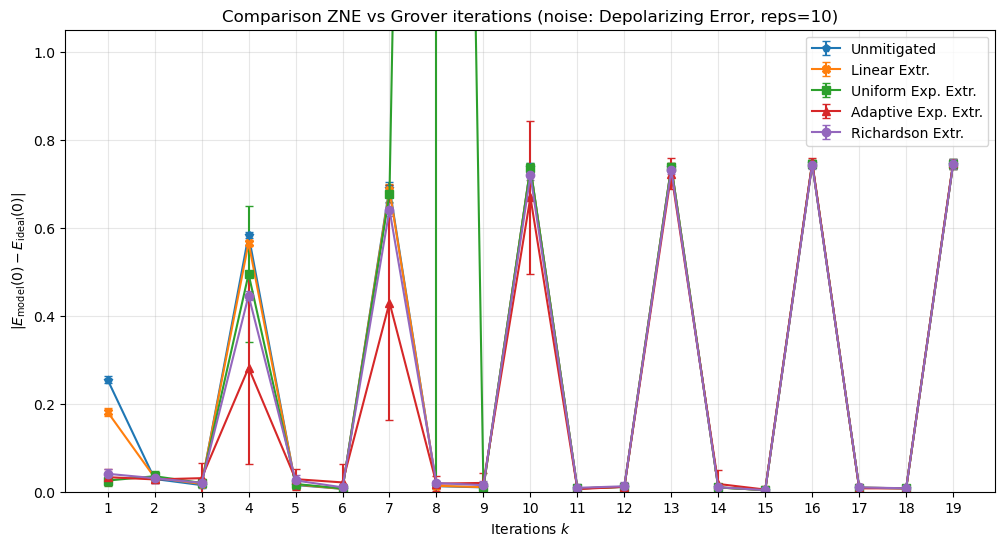

In [40]:
results = comparison_iterations(backends[0])

In [41]:
def plot_only_peaks(results, peak_threshold=0.95):
    """
    Plot only peak iterations k, defined as those where the noiseless ideal success is high.
    """
    iterations = np.asarray(results["iterations"], dtype=int)
    ideal_vals = np.asarray(results["ideal"], dtype=float)

    # Peak definition: close to the maximum ideal success
    ideal_max = float(np.max(ideal_vals))
    mask = ideal_vals >= (peak_threshold * ideal_max)

    k_peaks = iterations[mask]

    mean = results["err_mean"]
    std = results["err_std"]

    mean_un = np.asarray(mean["unmitigated"], dtype=float)[mask]
    mean_lin = np.asarray(mean["linear"], dtype=float)[mask]
    mean_rich = np.asarray(mean["richardson"], dtype=float)[mask]
    mean_exp = np.asarray(mean["uniform_exp"], dtype=float)[mask]
    mean_ad = np.asarray(mean["adaptive_exp"], dtype=float)[mask]

    std_un = np.asarray(std["unmitigated"], dtype=float)[mask]
    std_lin = np.asarray(std["linear"], dtype=float)[mask]
    std_rich = np.asarray(std["richardson"], dtype=float)[mask]
    std_exp = np.asarray(std["uniform_exp"], dtype=float)[mask]
    std_ad = np.asarray(std["adaptive_exp"], dtype=float)[mask]

    # If nothing selected, warn and exit
    if k_peaks.size == 0:
        print("No peaks found with this threshold. Try lowering peak_threshold (e.g., 0.9).")
        return

    plt.figure(figsize=(12, 6))

    ymax = float(np.max([
        mean_un + std_un,
        mean_lin + std_lin,
        mean_rich + std_rich,
        mean_exp + std_exp,
        mean_ad + std_ad
    ]))
    plt.ylim(0.0, min(1.05, ymax * 1.15 + 1e-6))

    plt.errorbar(k_peaks, mean_un, yerr=std_un, fmt="p-", label="Unmitigated", capsize=3)
    plt.errorbar(k_peaks, mean_lin, yerr=std_lin, fmt="X-", label="Linear Extr.", capsize=3)
    plt.errorbar(k_peaks, mean_exp, yerr=std_exp, fmt="s-", label="Uniform Exp. Extr.", capsize=3)
    plt.errorbar(k_peaks, mean_ad, yerr=std_ad, fmt="^-", label="Adaptive Exp. Extr.", capsize=3)
    plt.errorbar(k_peaks, mean_rich, yerr=std_rich, fmt="o-", label="Richardson Extr.", capsize=3)

    plt.xticks(k_peaks)
    plt.xlabel(r"Peak iterations $k$")
    plt.ylabel(r"$|E_{\mathrm{model}}(0) - E_{\mathrm{ideal}}(0)|$")
    plt.title(f"Comparison ZNE vs Grover's iterations (peaks)")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    print("Peak k values:", k_peaks.tolist())


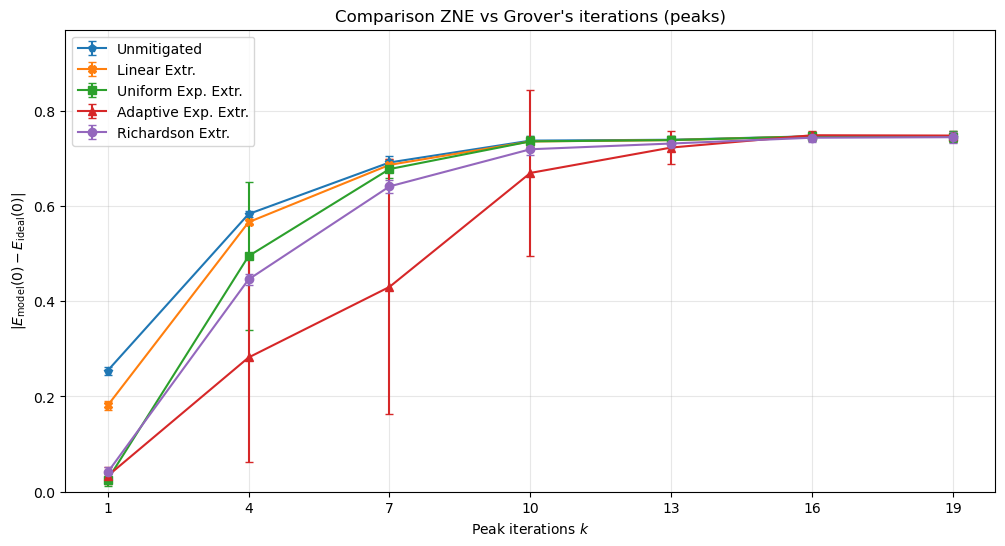

Peak k values: [1, 4, 7, 10, 13, 16, 19]


In [42]:
plot_only_peaks(results)